In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns',None)

In [2]:
df=pd.read_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_outlier_remove.csv')

In [3]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,house,independent,sector 4,0.58,9619.0,603.0,Plot area 67(6.22 sq.m.),2,2,1,2.0,West,Moderately Old,NaN,67.0,NaN,0,0,0,1,1,1,7,301.500000
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,3,4,3,3.0,North,Relatively New,1450.0,NaN,1177.0,1,1,0,0,0,1,49,483.333333
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,3.0,North,Relatively New,1485.0,NaN,NaN,0,0,0,0,0,2,7,495.000000
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,7.0,NaN,Under Construction,1820.0,NaN,NaN,0,0,0,0,0,1,24,606.666667
4,flat,dlf the ultima,sector 81,2.20,10461.0,2103.0,Super Built up area 2103(195.38 sq.m.)Built Up...,3,3,3+,5.0,East,Relatively New,2103.0,1570.0,1257.0,1,1,0,1,1,0,49,701.000000


In [4]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                139
facing                  990
agePossession             0
super_built_up_area    1610
built_up_area          1962
carpet_area            1661
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

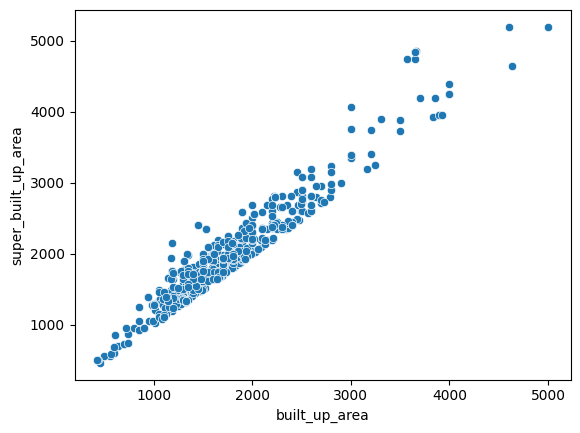

In [6]:
sns.scatterplot(x=df['built_up_area'],y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

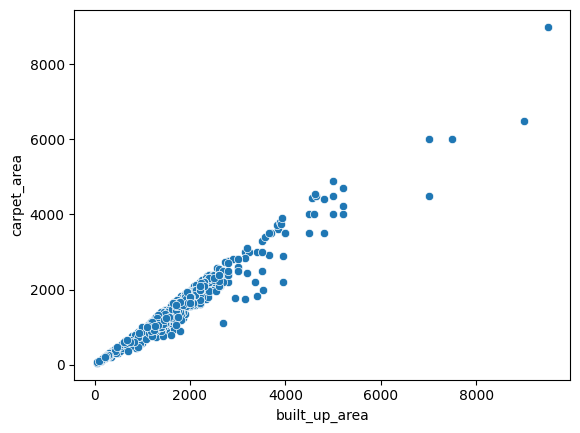

In [7]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'])

In [10]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())).isnull().sum()

np.int64(0)

In [11]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [12]:
all_present_df.shape

(531, 24)

In [13]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [14]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [15]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [16]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [17]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,3,4,3,3.0,North,Relatively New,1450.0,NaN,1177.0,1,1,0,0,0,1,49,483.333333
10,flat,m3m woodshire,sector 107,1.80,7623.0,2361.0,Super Built up area 2361(219.34 sq.m.)Carpet a...,3,4,3+,2.0,NaN,Relatively New,2361.0,NaN,1384.0,0,1,0,0,0,1,129,787.000000
15,flat,ramson kshitij sec-95 gurugram,sector 95,0.27,2700.0,1000.0,Super Built up area 1000(92.9 sq.m.)Carpet are...,2,2,0,1.0,West,Undefined,1000.0,NaN,550.0,0,0,0,0,0,1,0,500.000000
31,flat,tulip violet,sector 69,1.36,8618.0,1578.0,Super Built up area 1578(146.6 sq.m.)Carpet ar...,3,3,1,12.0,West,Relatively New,1578.0,NaN,1039.0,0,0,0,1,0,1,95,526.000000
41,flat,dlf the ultima,sector 81,2.30,14603.0,1575.0,Super Built up area 2100(195.1 sq.m.)Carpet ar...,3,4,3+,27.0,East,Relatively New,2100.0,NaN,1575.0,0,1,0,0,0,2,119,525.000000


In [19]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-co

In [20]:
df.update(sbc_df)

In [21]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                139
facing                  990
agePossession             0
super_built_up_area    1610
built_up_area          1541
carpet_area            1661
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [22]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [23]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2,flat,chd avenue,sector 71,1.00,6734.0,1485.0,Super Built up area 1485(137.96 sq.m.),3,3,3+,3.0,North,Relatively New,1485.0,NaN,NaN,0,0,0,0,0,2,7,495.000000
3,flat,ild grand,sector 37c,1.20,6593.0,1820.0,Super Built up area 1820(169.08 sq.m.),3,3,3,7.0,NaN,Under Construction,1820.0,NaN,NaN,0,0,0,0,0,1,24,606.666667
12,flat,antriksh heights,sector 84,0.49,4355.0,1125.0,Super Built up area 1125(104.52 sq.m.),2,2,2,16.0,East,Relatively New,1125.0,NaN,NaN,0,0,0,0,0,1,66,562.500000
14,flat,emaar mgf emerald floors premier,sector 65,2.25,13636.0,1650.0,Super Built up area 1650(153.29 sq.m.),3,3,3+,3.0,South,Relatively New,1650.0,NaN,NaN,1,1,0,0,0,1,152,550.000000
17,flat,shapoorji pallonji joyville gurugram,sector 102,1.26,10041.0,1255.0,Super Built up area 1215(112.88 sq.m.),2,2,2,10.0,North,Relatively New,1215.0,NaN,NaN,0,0,0,0,0,1,108,627.500000


In [24]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(rou

In [25]:
df.update(sb_df)

In [26]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                139
facing                  990
agePossession             0
super_built_up_area    1610
built_up_area           666
carpet_area            1661
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [27]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [28]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
6,flat,essel tower,sector 28,2.20,12500.0,1760.0,Carpet area: 1760 (163.51 sq.m.),3,4,3+,3.0,NaN,Moderately Old,NaN,NaN,1760.0,0,1,0,0,0,0,0,586.666667
7,flat,apex builders,sector 37c,0.42,5600.0,750.0,Carpet area: 750 (69.68 sq.m.),2,2,2,4.0,North,Relatively New,NaN,NaN,750.0,0,0,0,0,0,1,42,375.000000
8,flat,signature global solera,sector 107,0.28,5828.0,480.0,Carpet area: 489 (45.43 sq.m.),2,2,2,11.0,South,Relatively New,NaN,NaN,489.0,0,0,0,0,0,1,45,240.000000
19,flat,denso haryana housing society,manesar,0.90,4308.0,2089.0,Carpet area: 2089 (194.07 sq.m.),3,3,3+,5.0,East,Moderately Old,NaN,NaN,2089.0,0,1,0,0,0,1,7,696.333333
25,flat,smart world orchard,sector 61,1.58,13739.0,1150.0,Carpet area: 1150 (106.84 sq.m.),2,2,2,3.0,South,New Property,NaN,NaN,1150.0,1,0,0,0,0,1,15,575.000000


In [29]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carp

In [30]:
df.update(c_df)

In [31]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                139
facing                  990
agePossession             0
super_built_up_area    1610
built_up_area             0
carpet_area            1661
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

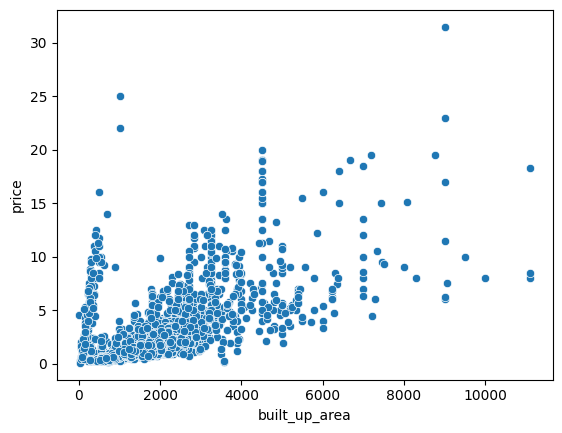

In [32]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [33]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [34]:
anamoly_df.sample(5)

,price,area,built_up_area
518,8.25,2160.0,300.0
494,11.00,2700.0,361.0
1449,6.50,1800.0,1800.0
3265,2.80,2048.0,1853.0
974,2.57,1630.0,1811.0


In [35]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [36]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

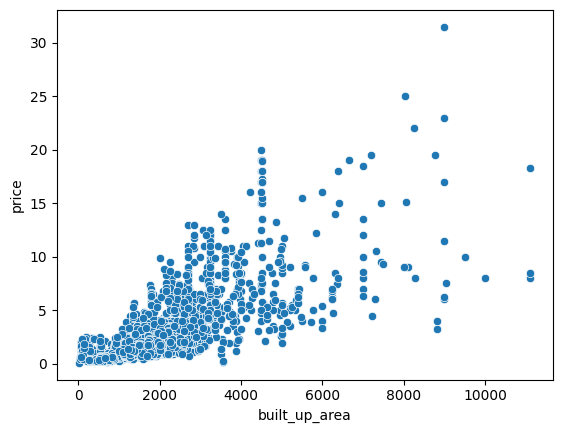

In [37]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [38]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [39]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,0.58,9619.0,2,2,1,2.0,West,Moderately Old,67.0,0,0,0,1,1,1,7
1,flat,emaar mgf palm hills,sector 77,1.25,8620.0,3,4,3,3.0,North,Relatively New,1310.0,1,1,0,0,0,1,49
2,flat,chd avenue,sector 71,1.00,6734.0,3,3,3+,3.0,North,Relatively New,1344.0,0,0,0,0,0,2,7
3,flat,ild grand,sector 37c,1.20,6593.0,3,3,3,7.0,NaN,Under Construction,1647.0,0,0,0,0,0,1,24
4,flat,dlf the ultima,sector 81,2.20,10461.0,3,3,3+,5.0,East,Relatively New,1570.0,1,1,0,1,1,0,49


In [40]:
df.isnull().sum()

property_type        0
society              1
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum           139
facing             990
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

### floorNUM

In [41]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
63,flat,ireo victory valley,sector 67,4.50,14097.0,4,4,3+,NaN,North,Relatively New,3160.0,0,1,0,1,0,2,42
134,flat,lig flat,sector 40,1.50,5556.0,1,1,0,NaN,NaN,Undefined,300.0,0,0,0,0,0,1,0
141,flat,conscient elevate,sector 59,3.90,16993.0,3,1,0,NaN,NaN,Undefined,2295.0,0,0,0,0,0,1,0
159,flat,orchid petals,sector 49,2.09,11578.0,3,3,3,NaN,South,Relatively New,1633.0,0,0,0,0,0,1,49
161,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3373,house,independent,sector 26,4.60,12198.0,4,4,3+,NaN,NaN,Old Property,3771.0,0,0,0,0,0,1,28
3414,flat,tulip violet,sector 69,1.75,9459.0,3,4,2,NaN,East,Relatively New,2056.0,0,0,0,0,0,2,174
3419,flat,tulip violet,sector 69,2.00,9950.0,4,4,2,NaN,West,Relatively New,1819.0,0,0,0,0,0,1,95
3445,flat,kendriya vihar,sector 56,0.65,8609.0,1,1,1,NaN,NaN,Moderately Old,839.0,0,0,0,0,0,1,143


In [42]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [43]:
df['floorNum'].fillna(2.0,inplace=True)

C:\Users\8429s\AppData\Local\Temp\ipykernel_25524\15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [44]:
df.isnull().sum()

property_type        0
society              1
sector               0
price                0
price_per_sqft       0
bedRoom              0
bathroom             0
balcony              0
floorNum             0
facing             990
agePossession        0
built_up_area        0
study room           0
servant room         0
store room           0
pooja room           0
others               0
furnishing_type      0
luxury_score         0
dtype: int64

### facing 

<Axes: ylabel='count'>

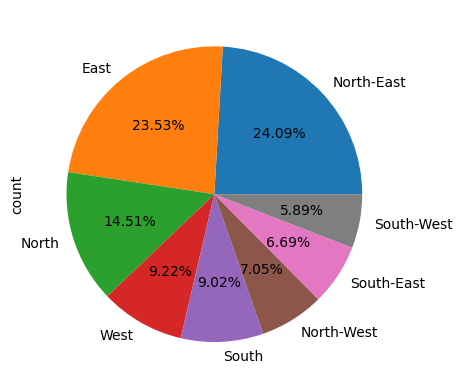

In [45]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [46]:
df.drop(columns=['facing'],inplace=True)

In [47]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
153,flat,zara aavaas,sector 104,0.40,7029.0,2,2,1,14.0,Relatively New,515.0,0,0,0,0,0,1,38
2591,flat,om apartment dayanand colony,sector 5,0.26,4373.0,1,1,1,3.0,Relatively New,648.0,0,0,0,0,0,1,14
3443,flat,godrej frontier,sector 80,1.40,6189.0,3,4,2,10.0,Moderately Old,1854.0,0,0,1,1,0,1,111
1602,flat,dlf the ultima,sector 81,2.70,12802.0,3,3,3,15.0,Relatively New,2343.0,0,1,0,0,0,2,49
2559,house,emaar mgf marbella,sector 66,8.70,38667.0,4,5,2,3.0,New Property,2250.0,1,1,0,0,0,1,144


In [48]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [49]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2546,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,0


In [50]:
df.drop(index=[2546],inplace=True)

In [51]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossesion

In [52]:
df['agePossession'].value_counts()

agePossession
Relatively New        1589
New Property           550
Moderately Old         518
Undefined              295
Old Property           278
Under Construction     254
Name: count, dtype: int64

In [53]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
15,flat,ramson kshitij sec-95 gurugram,sector 95,0.27,2700.0,2,2,0,1.0,Undefined,758.0,0,0,0,0,0,1,0
24,flat,trisara our homes 3,sohna road,0.40,4478.0,2,2,2,1.0,Undefined,900.0,0,0,0,0,0,1,0
42,flat,ramprasta awho,sector 95,0.92,5257.0,3,3,3+,13.0,Undefined,1750.0,0,0,0,0,0,1,0
62,house,independent,sector 67,3.00,11904.0,4,4,0,3.0,Undefined,2800.0,0,0,0,0,0,1,0
80,house,independent,sector 38,8.00,25616.0,10,10,3+,1.0,Undefined,3123.0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3350,house,independent,sector 56,2.95,20233.0,2,2,0,1.0,Undefined,1458.0,0,0,0,0,0,1,0
3354,flat,umang winter hills,sector 77,1.20,6586.0,3,3,3,14.0,Undefined,1822.0,0,0,0,0,0,1,46
3374,house,bhim nagar society,sector 6,0.40,2500.0,4,2,2,1.0,Undefined,1600.0,0,0,0,0,0,1,0
3425,flat,sare green parc,sector 92,0.75,4820.0,3,2,2,16.0,Undefined,1556.0,0,0,0,0,0,1,0


In [54]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [55]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [56]:
df['agePossession'].value_counts()

agePossession
Relatively New        1698
New Property           591
Moderately Old         553
Old Property           316
Under Construction     268
Undefined               58
Name: count, dtype: int64

In [57]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [58]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [59]:
df['agePossession'].value_counts()

agePossession
Relatively New        1710
New Property           593
Moderately Old         556
Old Property           319
Under Construction     269
Undefined               37
Name: count, dtype: int64

In [60]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [61]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [62]:
df['agePossession'].value_counts()

agePossession
Relatively New        1712
New Property           593
Moderately Old         591
Old Property           319
Under Construction     269
Name: count, dtype: int64

In [63]:
df.isnull().sum()

property_type      0
society            0
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [64]:
df.to_csv('C:/Users/8429s/OneDrive/Desktop/Placement/Projects/Real Estate Price Prediction and Recommendation System/Data_Clean/flats_and_house_missing_value_immputation.csv',index=False)